In [16]:
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# ==============================
# Load Dataset
# ==============================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ==============================
# Select Required Features
# ==============================
df = df[[
    "tenure",
    "MonthlyCharges",
    "Contract",
    "InternetService",
    "PaymentMethod",
    "Churn"
]]

# ==============================
# Feature Engineering
# ==============================
df["TotalCharges"] = df["tenure"] * df["MonthlyCharges"]

# ==============================
# Handle Missing Values
# ==============================
df.dropna(inplace=True)

# ==============================
# Convert Target
# ==============================
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==============================
# One-Hot Encoding
# ==============================
df = pd.get_dummies(df, drop_first=True)

# ==============================
# Split Features & Target
# ==============================
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Save column names
model_columns = X.columns.tolist()

# ==============================
# Handle Imbalance
# ==============================
sm = SMOTE(random_state=42)
X, y = sm.fit_resample(X, y)

# ==============================
# Train Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# Scaling
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# Model Training
# ==============================
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

# ==============================
# Evaluation
# ==============================
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ==============================
# Save Model
# ==============================
pickle.dump(model, open("churn_model.pkl", "wb"))
pickle.dump(model_columns, open("model_columns.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

Accuracy: 0.8169082125603865
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1021
           1       0.82      0.83      0.82      1049

    accuracy                           0.82      2070
   macro avg       0.82      0.82      0.82      2070
weighted avg       0.82      0.82      0.82      2070



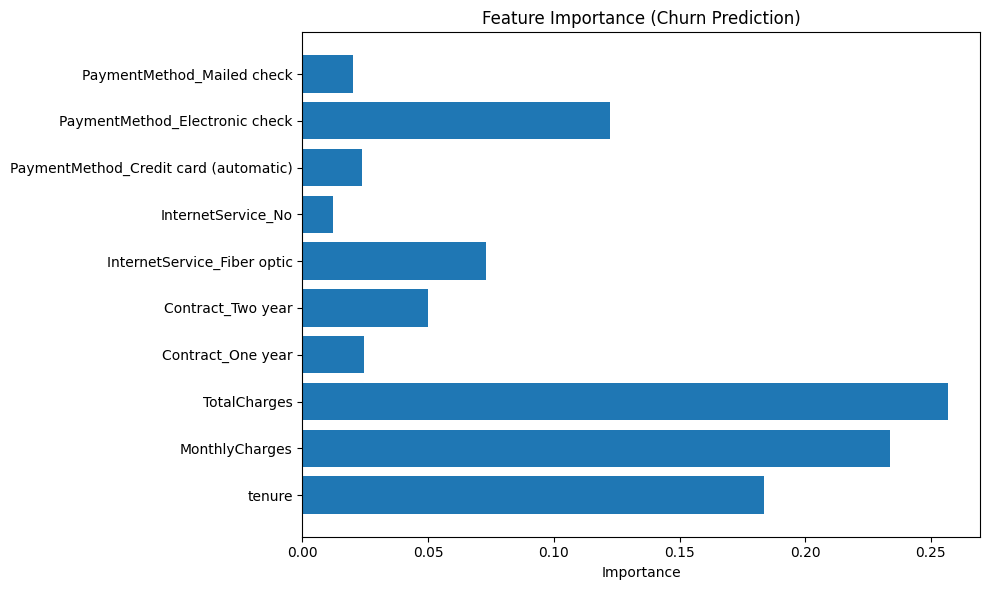

In [17]:
import matplotlib.pyplot as plt

# Feature Importance
importances = model.feature_importances_
feature_names = X.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Churn Prediction)")
plt.tight_layout()
plt.show()

In [18]:
df.head(5)

,tenure,MonthlyCharges,Churn,TotalCharges,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,0,29.85,False,False,False,False,False,True,False
1,34,56.95,0,1936.30,True,False,False,False,False,False,True
2,2,53.85,1,107.70,False,False,False,False,False,False,True
3,45,42.30,0,1903.50,True,False,False,False,False,False,False
4,2,70.70,1,141.40,False,False,True,False,False,True,False


In [ ]:
#print("Accuracy xgboost:", accuracy_score(y_test, xgb_pred))
#print("Accuracy rfc:", accuracy_score(y_test, rf_pred))
#print("Accuracy lr:", accuracy_score(y_test, lr_pred))

In [ ]:
#import matplotlib.pyplot as plt

""" importances = rf_model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show() """

In [ ]:
""" import pickle

# save model
pickle.dump(rf_model, open("churn_model.pkl","wb"))

# save column order
pickle.dump(X.columns.tolist(), open("model_columns.pkl","wb")) """